# Notebook 4: Rolling-Window Analysis

The baseline OLS in Notebook 3 gives me one coefficient per market across the entire sample. But the full-sample coefficient is an average over very different market regimes: calm 2018 to 2019, the COVID crash, the post-pandemic recovery, the Russia-Ukraine shock, and the 2023 to 2024 normalisation. If the underlying relationship changes between these periods, the full-sample average shows interesting structure.

The rolling-window approach re-estimates the same regression in overlapping 252-day windows (roughly one trading year), producing a time series of coefficients that I can plot against time. This analyzes if the predictive relationship deepens during crises, weakens during calm periods, or stays approximately constant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

df = pd.read_parquet("../data/regression_data.parquet")

print(f"Observations: {len(df)}")
print(f"Date range:   {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Observations: 1635
Date range:   2018-01-04 to 2024-12-23


,VIX_level,VIX_change,WIG20_next,BUX_next,PX_next,ATX_next
Date,,,,,,
2018-01-04,9.22,0.070001,-0.001430,0.003636,0.000172,0.000124
2018-01-05,9.22,0.000000,0.007507,0.002718,0.003252,-0.000183
2018-01-08,9.52,0.300000,-0.007969,-0.005864,-0.004012,0.002336
2018-01-09,10.08,0.559999,-0.006790,-0.005491,-0.002493,0.009308
2018-01-10,9.82,-0.260000,0.009231,0.003060,0.005386,0.002765


## Load the Data

Same `regression_data.parquet`.

In [ ]:
def rolling_ols(y, X, window=252, lags=5):
    """
    Run rolling-window OLS regressions.
    
    At each date t, fit OLS on the prior `window` observations,
    extract the VIX_change coefficient, its standard error, and t-stat.
    
    Parameters
    ----------
    y : pd.Series
        Dependent variable (next-day return).
    X : pd.DataFrame
        Independent variables (without constant).
    window : int
        Number of observations in each rolling window. 252 = one trading year.
    lags : int
        Newey-West lag length.
    
    Returns
    -------
    pd.DataFrame indexed by date with columns:
      coef       : VIX_change coefficient
      se         : Newey-West standard error
      ci_low     : lower 95% CI
      ci_high    : upper 95% CI
      r_squared  : window R²
    """

    
    n = len(y)
    out = []
    
    for t in range(window, n + 1):
        y_win = y.iloc[t - window : t]
        X_win = X.iloc[t - window : t]
        X_with_const = sm.add_constant(X_win)
        
        try:
            res = sm.OLS(y_win, X_with_const).fit(
                cov_type="HAC", cov_kwds={"maxlags": lags}
            )
            coef = res.params["VIX_change"]
            se   = res.bse["VIX_change"]
            ci   = res.conf_int(alpha=0.05).loc["VIX_change"]
            r2   = res.rsquared
        except Exception:
            coef = se = r2 = np.nan
            ci = [np.nan, np.nan]
        
        out.append({
            "date"      : y.index[t - 1],   # window ends here
            "coef"      : coef,
            "se"        : se,
            "ci_low"    : ci[0],
            "ci_high"   : ci[1],
            "r_squared" : r2,
        })
    
    return pd.DataFrame(out).set_index("date")

# quick test on WIG20, should take no more than 10 seconds
print("Testing...")
test_rolling = rolling_ols(df["WIG20_next"], df[["VIX_level", "VIX_change"]])
print(f"\nRolling windows: {len(test_rolling)}")
print(f"Date range: {test_rolling.index[0].date()} to {test_rolling.index[-1].date()}")
test_rolling.head()

## Define the Rolling Regression Function

The function takes the same dependent and independent variables as in Notebook 3, but instead of running one regression on the full sample, it loops through every possible 252-day window, fits the regression on that window's data, and extracts the VIX_change coefficient plus its Newey-West standard error.

Shorter windows (e.g. 126 days) produce too much noise due to each each estimate is based on too few observations, and the coefficient bounces around even when nothing economic is happening. Longer windows (e.g. 504 days) smooth over the regime changes I want to identify. One year of trading data is the standard compromise in the specialized literature and research.

I dated each window by its endpoint, which is a convention.Coefficient plotted on March 2021, for example, is estimated on data from roughly March 2020 to March 2021.

The full procedure takes about 5 to 10 seconds on one market. With four markets it's under a minute.

In [ ]:
markets = ["WIG20", "BUX", "PX", "ATX"]
rolling_results = {}

print("Running rolling regressions for all four markets...\n")
for mkt in markets:
    print(f"  {mkt}...", end=" ")
    rolling_results[mkt] = rolling_ols(
        df[f"{mkt}_next"],
        df[["VIX_level", "VIX_change"]]
    )
    print(f"done ({len(rolling_results[mkt])} windows)")

# save the coefficient series for the paper appendix
rolling_summary = pd.concat(
    {mkt: rolling_results[mkt]["coef"] for mkt in markets},
    axis=1
)
rolling_summary.to_parquet("../data/rolling_coefficients.parquet")

# summary statistics on how the coefficient varies through time
print("\nRolling-window coefficient summary:\n")
stats_table = pd.DataFrame({
    "Mean coef"    : rolling_summary.mean(),
    "Min coef"     : rolling_summary.min(),
    "Max coef"     : rolling_summary.max(),
    "Std dev"      : rolling_summary.std(),
    "% windows < 0": (rolling_summary < 0).mean() * 100
}).round(5)
print(stats_table)

Running rolling regressions for all four markets...

  WIG20... done (1384 windows)
  BUX... done (1384 windows)
  PX... done (1384 windows)
  ATX... done (1384 windows)

Saved → data/rolling_coefficients.parquet

Rolling-window coefficient summary:

       Mean coef  Min coef  Max coef  Std dev  % windows < 0
WIG20   -0.00115  -0.00252   0.00074  0.00067       97.32659
BUX     -0.00088  -0.00240   0.00086  0.00052       98.98844
PX      -0.00075  -0.00148   0.00097  0.00038       97.83237
ATX     -0.00099  -0.00200   0.00135  0.00044       99.34971


## Run Rolling Regressions for All Four Markets

The loop produces 1,384 coefficients per market (the maximum number of complete 252-day windows in the 1,635-observation sample). 

I want to see how often the coefficient is negative. If the predictive relationship is real, it should be negative in the great majority of windows even if magnitude varies. If so, the full-sample result is probably driven by a few outlier periods.

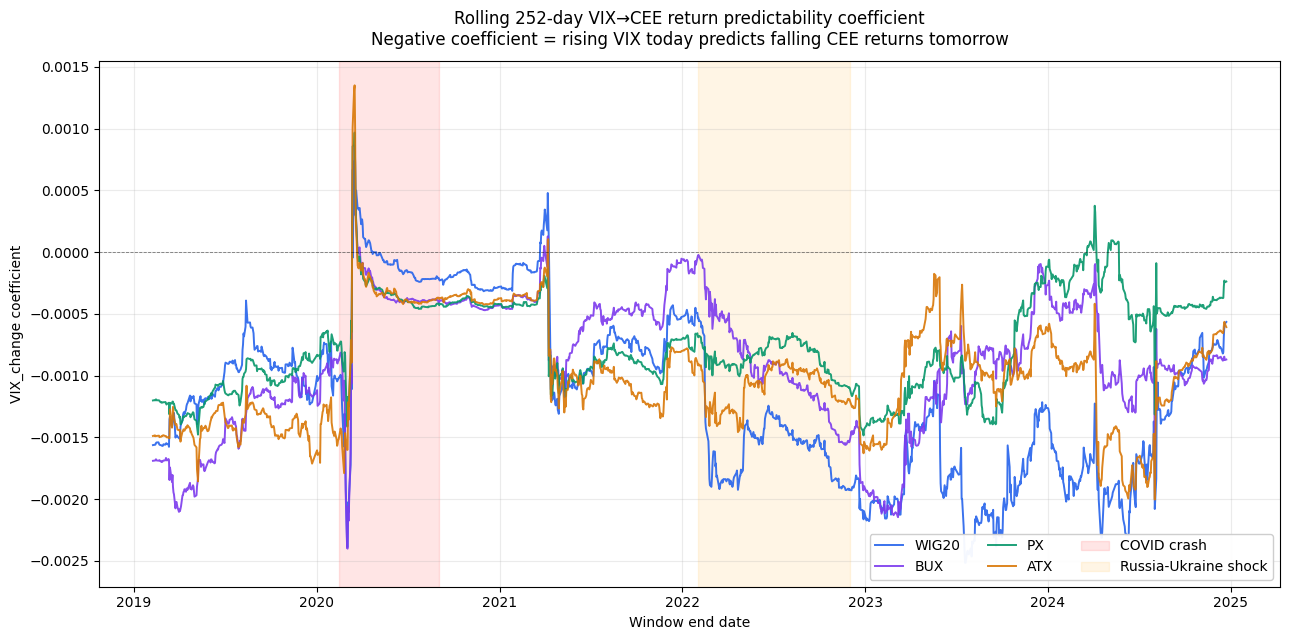

Saved → figures/05_rolling_coefficients.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6.5))

colors = {"WIG20": "#2563eb", "BUX": "#7c3aed",
          "PX": "#059669", "ATX": "#d97706"}

# main panel: rolling coefficients for all four markets
for mkt in markets:
    ax.plot(
        rolling_results[mkt].index,
        rolling_results[mkt]["coef"],
        color=colors[mkt],
        linewidth=1.4,
        label=mkt,
        alpha=0.9
    )

# zero line
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)

# shade crisis periods
covid_start = pd.Timestamp("2020-02-15")
covid_end   = pd.Timestamp("2020-09-01")
ukraine_start = pd.Timestamp("2022-02-01")
ukraine_end   = pd.Timestamp("2022-12-01")

ax.axvspan(covid_start, covid_end, alpha=0.10, color="red",
           label="COVID crash")
ax.axvspan(ukraine_start, ukraine_end, alpha=0.10, color="orange",
           label="Russia-Ukraine shock")

# formatting
ax.set_title("Rolling 252-day VIX→CEE return predictability coefficient\n"
             "Negative coefficient = rising VIX today predicts falling CEE returns tomorrow",
             fontsize=12, fontweight="500", pad=12)
ax.set_xlabel("Window end date", fontsize=10)
ax.set_ylabel("VIX_change coefficient", fontsize=10)
ax.legend(loc="lower right", fontsize=10, ncol=3, framealpha=0.95)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(labelsize=10)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../figures/05_rolling_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

df = pd.read_parquet("../data/regression_data.parquet")
print(f"Observations: {len(df)}")
print(f"Date range:   {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Observations: 1635
Date range:   2018-01-04 to 2024-12-23


,VIX_level,VIX_change,WIG20_next,BUX_next,PX_next,ATX_next
Date,,,,,,
2018-01-04,9.22,0.070001,-0.001430,0.003636,0.000172,0.000124
2018-01-05,9.22,0.000000,0.007507,0.002718,0.003252,-0.000183
2018-01-08,9.52,0.300000,-0.007969,-0.005864,-0.004012,0.002336
2018-01-09,10.08,0.559999,-0.006790,-0.005491,-0.002493,0.009308
2018-01-10,9.82,-0.260000,0.009231,0.003060,0.005386,0.002765


In [8]:
# define crisis regime: VIX > 25 (standard "fear threshold" in the literature)
# also create a sample-median regime for robustness
threshold_crisis = 25
threshold_median = df["VIX_level"].median()

df["regime_crisis"] = (df["VIX_level"] > threshold_crisis).astype(int)
df["regime_median"] = (df["VIX_level"] > threshold_median).astype(int)

# count observations in each regime
print("Regime definitions:\n")
print(f"  Crisis threshold (VIX > 25):")
print(f"    High-fear days: {df['regime_crisis'].sum()} ({df['regime_crisis'].mean()*100:.1f}%)")
print(f"    Low-fear days:  {(1-df['regime_crisis']).sum()} ({(1-df['regime_crisis'].mean())*100:.1f}%)")
print()
print(f"  Median threshold (VIX > {threshold_median:.2f}):")
print(f"    High-fear days: {df['regime_median'].sum()} ({df['regime_median'].mean()*100:.1f}%)")
print(f"    Low-fear days:  {(1-df['regime_median']).sum()} ({(1-df['regime_median'].mean())*100:.1f}%)")

# brief check: what dates fall in the crisis regime?
crisis_dates = df[df["regime_crisis"] == 1].index
print(f"\nFirst crisis day:  {crisis_dates[0].date()}")
print(f"Last crisis day:   {crisis_dates[-1].date()}")
print(f"\nMajor crisis clusters (by year):")
print(crisis_dates.to_series().dt.year.value_counts().sort_index())

Regime definitions:

  Crisis threshold (VIX > 25):
    High-fear days: 304 (18.6%)
    Low-fear days:  1331 (81.4%)

  Median threshold (VIX > 18.12):
    High-fear days: 817 (50.0%)
    Low-fear days:  818 (50.0%)

First crisis day:  2018-02-05
Last crisis day:   2024-12-18

Major crisis clusters (by year):
Date
2018     13
2019      1
2020    145
2021     20
2022    119
2023      2
2024      4
Name: count, dtype: int64
